<a href="https://colab.research.google.com/github/AnusreeMandal/SELAB/blob/main/SELAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tower Of Hanoi Problem**

In [ ]:
def tower_of_hanoi(n, source, target, auxiliary):
    if n == 1:
        return 1  # Single move
    return (
        tower_of_hanoi(n - 1, source, auxiliary, target) + 1 + tower_of_hanoi(n - 1, auxiliary, target, source)
    )



In [ ]:
n=6
tower_of_hanoi(n, 'A', 'C', 'B')


63

In [ ]:
import time

def measure_time():
    data = []
    for n in range(1, 21):
        start_time = time.time()
        moves = tower_of_hanoi(n, 'A', 'C', 'B')
        end_time = time.time()
        elapsed_time = end_time - start_time
        data.append((n, moves, elapsed_time))
    return data

data = measure_time()
print("n\tMoves\tTime (s)")
for n, moves, elapsed_time in data:
    print(f"{n}\t{moves}\t{elapsed_time:.6f}")


n	Moves	Time (s)
1	1	0.000003
2	3	0.000004
3	7	0.000003
4	15	0.000004
5	31	0.000007
6	63	0.000014
7	127	0.000026
8	255	0.000060
9	511	0.000117
10	1023	0.000266
11	2047	0.000439
12	4095	0.002085
13	8191	0.001871
14	16383	0.003610
15	32767	0.006942
16	65535	0.010931
17	131071	0.020141
18	262143	0.041261
19	524287	0.085453
20	1048575	0.165851


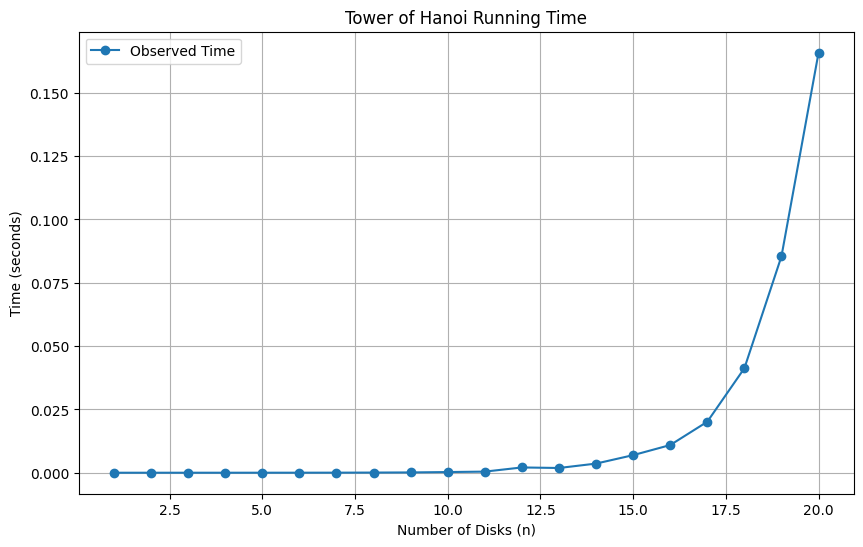

In [ ]:
import matplotlib.pyplot as plt

def plot_graph(data):
    n_values = [row[0] for row in data]
    times = [row[2] for row in data]

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, times, marker='o', label="Observed Time")
    plt.xlabel("Number of Disks (n)")
    plt.ylabel("Time (seconds)")
    plt.title("Tower of Hanoi Running Time")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_graph(data)

**Dijkstra's algorithm**

In [ ]:
import heapq

def dijkstra(graph, start):
    """
    Dijkstra's algorithm for shortest paths in a graph.
    :param graph: Dictionary representing the adjacency list of the graph
    :param start: Starting node
    :return: Dictionary of shortest distances from the start node
    """
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    priority_queue = [(0, start)]  # Use a list as a priority queue

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                heapq.heappush(priority_queue, (distance, neighbor))

    return distances




In [ ]:
import random
import time
def measure_time_dijkstra():
    """
    Measure and plot the running time of Dijkstra's algorithm.
    """
    global sizes, times
    sizes = [10, 30, 60, 90, 120, 170, 380, 590, 700, 1000]  # Number of nodes in the graph
    times = []

    for size in sizes:
        # Generate a random dense graph
        graph = {i: {j: random.randint(1, 10) for j in range(size) if i != j} for i in range(size)}

        start_node = 0
        start_time = time.time()
        dijkstra(graph, start_node)
        end_time = time.time()

        times.append(end_time - start_time)

    # Display tabular data
    print("\nDijkstra's Algorithm Running Time")
    print("------------------------------------")
    print("Nodes | Time (s)")
    for i in range(len(sizes)):
        print(f"{sizes[i]:5} | {times[i]:8.6f}")

measure_time_dijkstra()







Dijkstra's Algorithm Running Time
------------------------------------
Nodes | Time (s)
   10 | 0.000062
   30 | 0.000264
   60 | 0.000937
   90 | 0.001257
  120 | 0.002180
  170 | 0.003611
  380 | 0.017977
  590 | 0.044519
  700 | 0.065613
 1000 | 0.125391


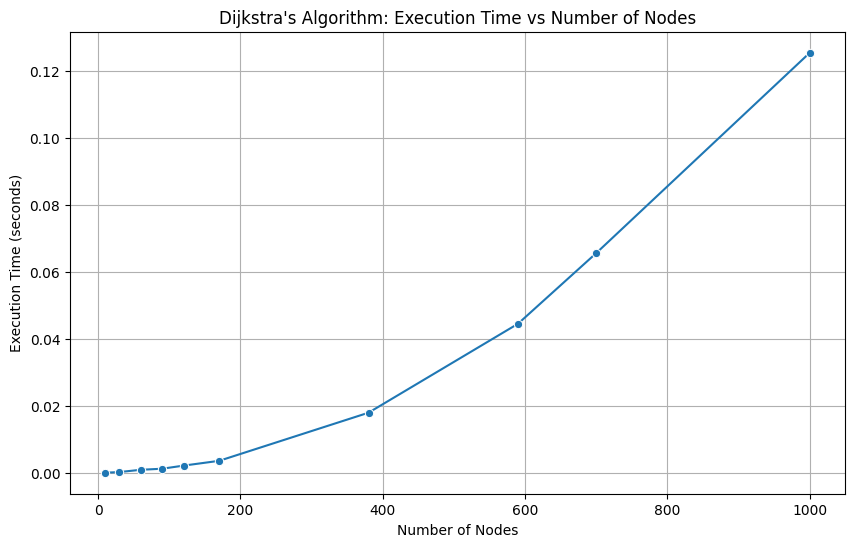

In [ ]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'sizes' and 'times' are defined from your previous code

# Create a Pandas DataFrame for better data handling with seaborn
import pandas as pd
df = pd.DataFrame({'Number of Nodes': sizes, 'Execution Time (seconds)': times})

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Number of Nodes', y='Execution Time (seconds)', data=df, marker='o')
plt.title("Dijkstra's Algorithm: Execution Time vs Number of Nodes")
plt.grid(True)
plt.show()

In [ ]:
# Justify theoretical time complexity
print("\nTheoretical Time Complexity Analysis:")
print("-------------------------------------")
print("Dijkstra's algorithm using a min-priority queue (like heapq in Python) has a time complexity of:")
print("O((V + E) * log(V))")
print("Where:")
print("  V = Number of vertices (nodes)")
print("  E = Number of edges")
print("\nIn our case, we're using dense graphs where E is approximately V^2.")
print("Therefore, the time complexity becomes closer to O(V^2 * log(V)).")

# Run the time measurement for Dijkstra's algorithm
measure_time_dijkstra()


Theoretical Time Complexity Analysis:
-------------------------------------
Dijkstra's algorithm using a min-priority queue (like heapq in Python) has a time complexity of:
O((V + E) * log(V))
Where:
  V = Number of vertices (nodes)
  E = Number of edges

In our case, we're using dense graphs where E is approximately V^2.
Therefore, the time complexity becomes closer to O(V^2 * log(V)).

Dijkstra's Algorithm Running Time
------------------------------------
Nodes | Time (s)
   10 | 0.000045
   30 | 0.000161
   60 | 0.001038
   90 | 0.006076
  120 | 0.001947
  170 | 0.004510
  380 | 0.021592
  590 | 0.044874
  700 | 0.073051
 1000 | 0.137087


**Kruskal's Algorithm**

In [ ]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # Path compression
        return self.parent[x]

    def union(self, x, y):
        rootX = self.find(x)
        rootY = self.find(y)
        if rootX != rootY:
            if self.rank[rootX] > self.rank[rootY]:
                self.parent[rootY] = rootX
            elif self.rank[rootX] < self.rank[rootY]:
                self.parent[rootX] = rootY
            else:
                self.parent[rootY] = rootX
                self.rank[rootX] += 1

def kruskal(n, edges):
    """Kruskal's algorithm to find the MST of a graph."""
    edges.sort(key=lambda x: x[2])  # Sort edges by weight
    uf = UnionFind(n)
    mst_weight = 0
    mst_edges = []

    for u, v, weight in edges:
        if uf.find(u) != uf.find(v):
            uf.union(u, v)
            mst_weight += weight
            mst_edges.append((u, v, weight))

    return mst_weight, mst_edges


In [ ]:
import random
import time

def generate_edges(n, density=0.5):
    """Generate a random set of edges for a graph with n nodes."""
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < density:
                weight = random.randint(1, 100)
                edges.append((i, j, weight))
    return edges


In [ ]:
def measure_kruskal_time():
    data = []
    for n in range(10, 1000, 100):  # Varying number of nodes from 10 to 1000
        edges = generate_edges(n, density=0.5)
        start_time = time.time()
        kruskal(n, edges)
        end_time = time.time()
        elapsed_time = end_time - start_time
        data.append((n, len(edges), elapsed_time))
    return data

data = measure_kruskal_time()
print("Nodes\tEdges\tTime (s)")
for nodes, edges, elapsed_time in data:
    print(f"{nodes}\t{edges}\t{elapsed_time:.6f}")

Nodes	Edges	Time (s)
10	25	0.000058
110	3019	0.005953
210	11065	0.014436
310	23947	0.033022
410	41678	0.061539
510	64842	0.156395
610	93095	0.217148
710	125998	0.297018
810	163531	0.390004
910	207020	0.503041


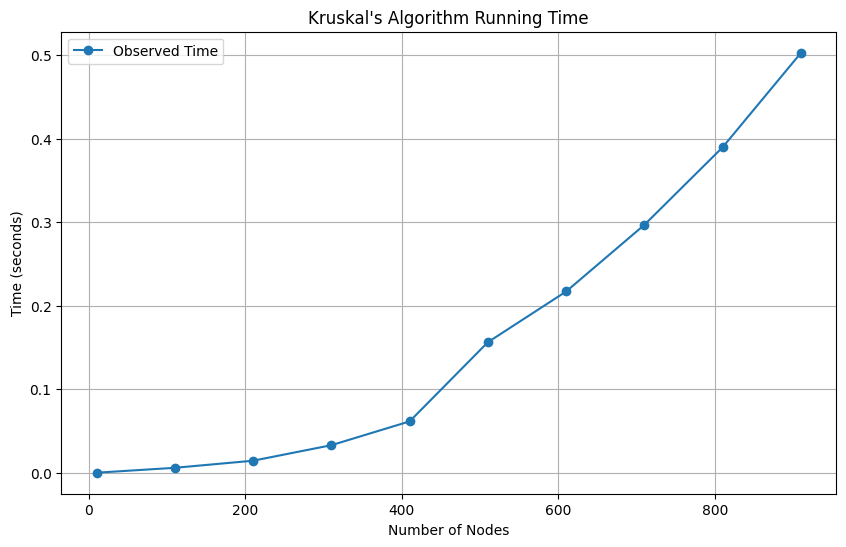

In [ ]:
import matplotlib.pyplot as plt

def plot_kruskal_graph(data):
    n_values = [row[0] for row in data]
    times = [row[2] for row in data]

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, times, marker='o', label="Observed Time")
    plt.xlabel("Number of Nodes")
    plt.ylabel("Time (seconds)")
    plt.title("Kruskal's Algorithm Running Time")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_kruskal_graph(data)

In [ ]:
# Theoretical Time Complexity for Kruskal's Algorithm

# Best Case:
# Sorting edges dominates; minimal Union-Find operations.
# Complexity: O(E * log(E))
best_case = "O(E * log(E))"

# Average Case:
# Sorting edges and Union-Find with nearly constant time α(V) per operation.
# Complexity: O(E * log(E) + E * α(V))
average_case = "O(E * log(E) + E * α(V))"

# Worst Case:
# Occurs in dense graphs where E = V^2.
# Complexity: O(E * log(E) + V^2)
worst_case = "O(E * log(E) + V^2)"

# Print the complexities
print("Theoretical Time Complexities for Kruskal's Algorithm:")
print(f"Best Case: {best_case}")
print(f"Average Case: {average_case}")
print(f"Worst Case: {worst_case}")

Theoretical Time Complexities for Kruskal's Algorithm:
Best Case: O(E * log(E))
Average Case: O(E * log(E) + E * α(V))
Worst Case: O(E * log(E) + V^2)


**Prim's Algorithm**

In [ ]:
import heapq

def prim(n, graph):
    """Prim's algorithm to find the MST of a graph."""
    mst_weight = 0
    mst_edges = []
    visited = [False] * n
    min_heap = [(0, 0)]  # (weight, node)

    while min_heap:
        weight, u = heapq.heappop(min_heap)

        if visited[u]:
            continue

        visited[u] = True
        mst_weight += weight

        for v, w in graph[u]:
            if not visited[v]:
                heapq.heappush(min_heap, (w, v))
                mst_edges.append((u, v, w))

    return mst_weight, mst_edges

In [ ]:
def generate_edges(n, density=0.5):
    """Generate a random set of edges for a graph with n nodes."""
    graph = [[] for _ in range(n)]  # Create an adjacency list for n nodes
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < density:
                weight = random.randint(1, 100)
                graph[i].append((j, weight))  # Add edge from i to j
                graph[j].append((i, weight))  # Add edge from j to i (undirected graph)
    return graph



In [ ]:
def measure_prim_time():
    data = []
    for n in range(10, 1001, 100):  # Varying number of nodes from 10 to 100
        graph = generate_edges(n, density=0.5)
        start_time = time.time()
        prim(n, graph)
        end_time = time.time()
        elapsed_time = end_time - start_time
        data.append((n, sum(len(row) for row in graph) // 2, elapsed_time))  # Calculate edges correctly
    return data

data = measure_prim_time()
print("Nodes\tEdges\tTime (s)")
for nodes, edges, elapsed_time in data:
    print(f"{nodes}\t{edges}\t{elapsed_time:.6f}")


Nodes	Edges	Time (s)
10	20	0.000036
110	2972	0.006212
210	10968	0.018713
310	24092	0.053712
410	42109	0.102776
510	64968	0.155487
610	93370	0.271013
710	125460	0.352795
810	163633	0.760988
910	206725	1.020994


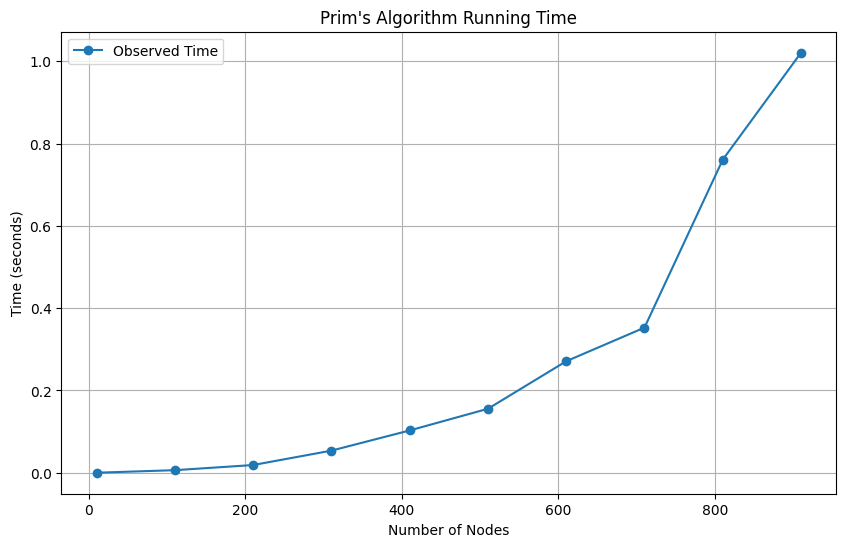

In [ ]:
import matplotlib.pyplot as plt

def plot_prim_graph(data):
    n_values = [row[0] for row in data]
    times = [row[2] for row in data]

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, times, marker='o', label="Observed Time")
    plt.xlabel("Number of Nodes")
    plt.ylabel("Time (seconds)")
    plt.title("Prim's Algorithm Running Time")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_prim_graph(data)


In [ ]:
# Theoretical Time Complexity for Prim's Algorithm

# Best Case:
# The graph is sparse, and Prim's algorithm runs efficiently with fewer edges.
# Complexity: O(E * log(V))
best_case = "O(E * log(V))"

# Average Case:
# The graph has a reasonable density of edges.
# Complexity: O(E * log(V))
average_case = "O(E * log(V))"

# Worst Case:
# Occurs in dense graphs where E = V^2.
# Complexity: O(V^2)
worst_case = "O(V^2)"

# Print the complexities
print("Theoretical Time Complexities for Prim's Algorithm:")
print(f"Best Case: {best_case}")
print(f"Average Case: {average_case}")
print(f"Worst Case: {worst_case}")


Theoretical Time Complexities for Prim's Algorithm:
Best Case: O(E * log(V))
Average Case: O(E * log(V))
Worst Case: O(V^2)


**knapsack algorithm**

Items	Time (s)
10	0.000396
20	0.000682
30	0.000773
40	0.000982
50	0.001882
60	0.002096
70	0.005637
80	0.002271
90	0.007054
100	0.003617


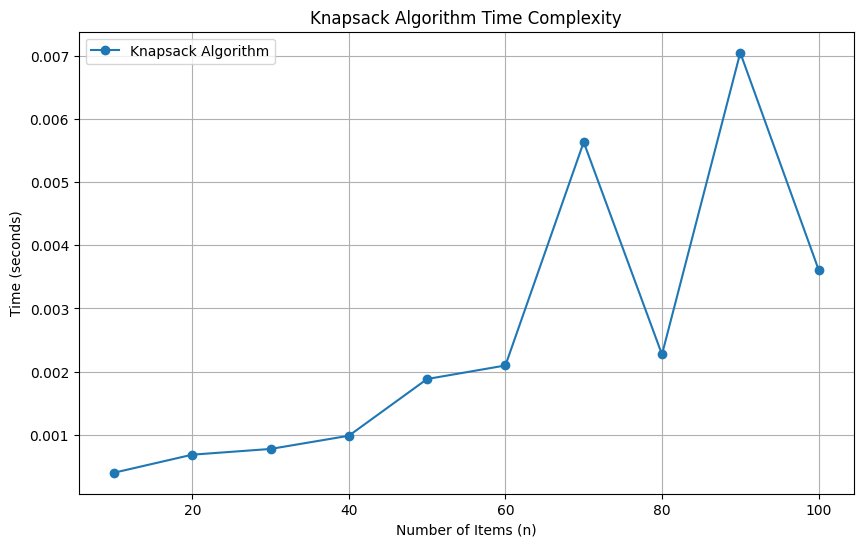

In [1]:
import time
import random
import matplotlib.pyplot as plt

def knapsack(weights, values, W, n):
    dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(1, W + 1):
            if weights[i - 1] <= w:
                dp[i][w] = max(dp[i - 1][w], dp[i - 1][w - weights[i - 1]] + values[i - 1])
            else:
                dp[i][w] = dp[i - 1][w]

    return dp[n][W]

def measure_knapsack_time():
    data = []
    for n in range(10, 101, 10):  # Varying number of items from 10 to 100
        weights = [random.randint(1, 50) for _ in range(n)]
        values = [random.randint(1, 100) for _ in range(n)]
        W = 50  # Fixed knapsack capacity
        start_time = time.time()
        knapsack(weights, values, W, n)
        end_time = time.time()
        elapsed_time = end_time - start_time
        data.append((n, elapsed_time))
    return data

def plot_knapsack_time(data):
    x, y = zip(*data)
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker='o', label="Knapsack Algorithm")
    plt.xlabel("Number of Items (n)")
    plt.ylabel("Time (seconds)")
    plt.title("Knapsack Algorithm Time Complexity")
    plt.grid()
    plt.legend()
    plt.show()

# Measure and plot
data = measure_knapsack_time()
print("Items\tTime (s)")
for n, elapsed_time in data:
    print(f"{n}\t{elapsed_time:.6f}")
plot_knapsack_time(data)

In [5]:
def print_time_complexity():
    print("\nTime Complexity Analysis for Knapsack Algorithm:")
    print("-------------------------------------------------")
    print("Best Case:")
    print("  - Time Complexity: O(n)")
    print("  - Explanation: Occurs when all item weights exceed the knapsack capacity (W)."
          " The algorithm only iterates through the items without performing inner loop operations.")
    print("\nAverage Case:")
    print("  - Time Complexity: O(n × W)")
    print("  - Explanation: Occurs when items have weights that are a mix of small and large values."
          " The algorithm computes the DP table for most items and capacities.")
    print("\nWorst Case:")
    print("  - Time Complexity: O(n × W)")
    print("  - Explanation: Happens when all items have weights less than or equal to W."
          " The algorithm fully fills the DP table, iterating over all items and capacities.")
    print("\nSpace Complexity:")
    print("  - Space Complexity: O(n × W)")
    print("  - Explanation: A 2D DP table is used to store results for subproblems.")

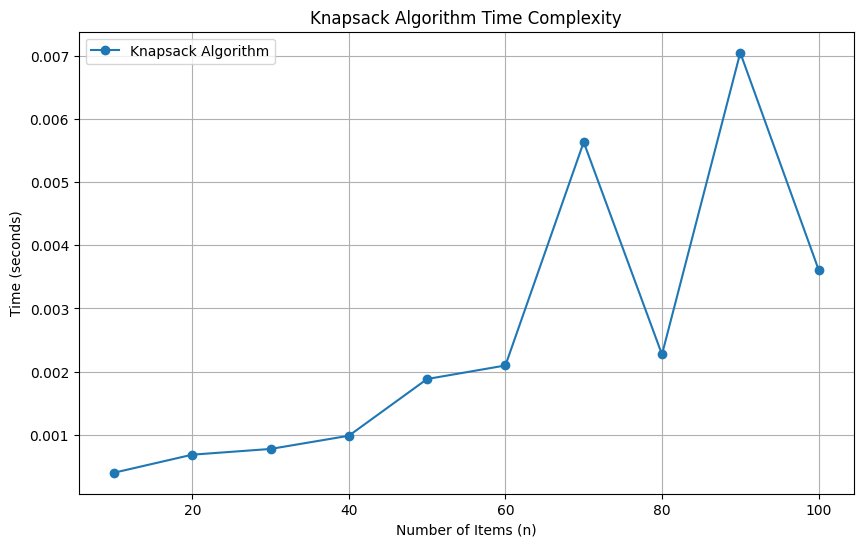


Time Complexity Analysis for Knapsack Algorithm:
-------------------------------------------------
Best Case:
  - Time Complexity: O(n)
  - Explanation: Occurs when all item weights exceed the knapsack capacity (W). The algorithm only iterates through the items without performing inner loop operations.

Average Case:
  - Time Complexity: O(n × W)
  - Explanation: Occurs when items have weights that are a mix of small and large values. The algorithm computes the DP table for most items and capacities.

Worst Case:
  - Time Complexity: O(n × W)
  - Explanation: Happens when all items have weights less than or equal to W. The algorithm fully fills the DP table, iterating over all items and capacities.

Space Complexity:
  - Space Complexity: O(n × W)
  - Explanation: A 2D DP table is used to store results for subproblems.


In [6]:
plot_knapsack_time(data)  # Plot the graph
print_time_complexity()   # Print the time complexity analysis



> **Floyd's** **Algorithm**



In [7]:
def floyd_warshall(graph):
    V = len(graph)
    dist = [[float('inf')] * V for _ in range(V)]

    # Initialize the distance matrix with the input graph
    for i in range(V):
        for j in range(V):
            dist[i][j] = graph[i][j]

    # Apply Floyd's Algorithm
    for k in range(V):
        for i in range(V):
            for j in range(V):
                dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])

    return dist


In [8]:
import time
import random

def generate_graph(V):
    """Generate a random weighted adjacency matrix for a graph with V vertices."""
    graph = [[float('inf') if i != j else 0 for j in range(V)] for i in range(V)]
    for i in range(V):
        for j in range(i + 1, V):
            weight = random.randint(1, 10)
            graph[i][j] = weight
            graph[j][i] = weight
    return graph

def measure_floyd_time():
    data = []
    for V in range(2, 101, 10):  # Varying number of vertices from 2 to 100
        graph = generate_graph(V)
        start_time = time.time()
        floyd_warshall(graph)
        elapsed_time = time.time() - start_time
        data.append((V, elapsed_time))
    return data

# Generate tabular data
data = measure_floyd_time()
print("Vertices\tTime (s)")
for V, elapsed_time in data:
    print(f"{V}\t\t{elapsed_time:.6f}")


Vertices	Time (s)
2		0.000012
12		0.001344
22		0.005547
32		0.011361
42		0.026423
52		0.046680
62		0.083730
72		0.124275
82		0.186284
92		0.285743


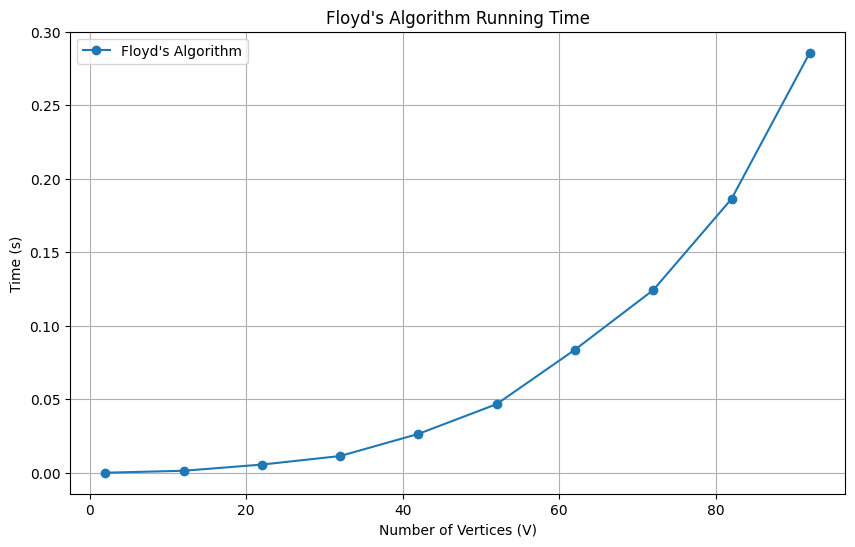

In [9]:
import matplotlib.pyplot as plt

def plot_floyd_time(data):
    vertices = [item[0] for item in data]
    times = [item[1] for item in data]

    plt.figure(figsize=(10, 6))
    plt.plot(vertices, times, marker='o', label="Floyd's Algorithm")
    plt.title("Floyd's Algorithm Running Time")
    plt.xlabel("Number of Vertices (V)")
    plt.ylabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot the graph
plot_floyd_time(data)


In [10]:
def print_floyd_time_complexity():
    print("\nTime Complexity Analysis for Floyd's Algorithm:")
    print("-------------------------------------------------")
    print("Best Case:")
    print("  - Time Complexity: O(V³)")
    print("  - Explanation: Floyd's Algorithm always processes all pairs of vertices, regardless of graph structure."
          " Thus, the best case is the same as the worst case.")
    print("\nAverage Case:")
    print("  - Time Complexity: O(V³)")
    print("  - Explanation: The algorithm iterates over all vertices as intermediate nodes and processes all pairs of vertices."
          " The time complexity remains cubic in nature.")
    print("\nWorst Case:")
    print("  - Time Complexity: O(V³)")
    print("  - Explanation: In dense graphs with many edges, the algorithm still performs cubic iterations over all vertex pairs."
          " There is no shortcut for dense graphs.")
    print("\nSpace Complexity:")
    print("  - Space Complexity: O(V²)")
    print("  - Explanation: A 2D matrix of size V × V is used to store the shortest paths between all pairs of vertices.")

# Print time complexity analysis
print_floyd_time_complexity()



Time Complexity Analysis for Floyd's Algorithm:
-------------------------------------------------
Best Case:
  - Time Complexity: O(V³)
  - Explanation: Floyd's Algorithm always processes all pairs of vertices, regardless of graph structure. Thus, the best case is the same as the worst case.

Average Case:
  - Time Complexity: O(V³)
  - Explanation: The algorithm iterates over all vertices as intermediate nodes and processes all pairs of vertices. The time complexity remains cubic in nature.

Worst Case:
  - Time Complexity: O(V³)
  - Explanation: In dense graphs with many edges, the algorithm still performs cubic iterations over all vertex pairs. There is no shortcut for dense graphs.

Space Complexity:
  - Space Complexity: O(V²)
  - Explanation: A 2D matrix of size V × V is used to store the shortest paths between all pairs of vertices.


**MERGE SORT ALGORITHM**

In [11]:
def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        left_half = arr[:mid]
        right_half = arr[mid:]

        # Recursively sort the halves
        merge_sort(left_half)
        merge_sort(right_half)

        # Merge the sorted halves
        i = j = k = 0
        while i < len(left_half) and j < len(right_half):
            if left_half[i] < right_half[j]:
                arr[k] = left_half[i]
                i += 1
            else:
                arr[k] = right_half[j]
                j += 1
            k += 1

        while i < len(left_half):
            arr[k] = left_half[i]
            i += 1
            k += 1

        while j < len(right_half):
            arr[k] = right_half[j]
            j += 1
            k += 1


In [12]:
import time
import random

def measure_merge_sort_time():
    data = []
    for n in range(1000, 20001, 1000):  # Array sizes from 1000 to 20000
        arr = [random.randint(1, 10000) for _ in range(n)]
        start_time = time.time()
        merge_sort(arr)
        elapsed_time = time.time() - start_time
        data.append((n, elapsed_time))
    return data

# Generate tabular data
data = measure_merge_sort_time()
print("Array Size\tTime (s)")
for size, elapsed_time in data:
    print(f"{size}\t\t{elapsed_time:.6f}")


Array Size	Time (s)
1000		0.005494
2000		0.009137
3000		0.012007
4000		0.024408
5000		0.021095
6000		0.025212
7000		0.030021
8000		0.041995
9000		0.040102
10000		0.047667
11000		0.081378
12000		0.106663
13000		0.205211
14000		0.122071
15000		0.131779
16000		0.161689
17000		0.157415
18000		0.159935
19000		0.172668
20000		0.180709


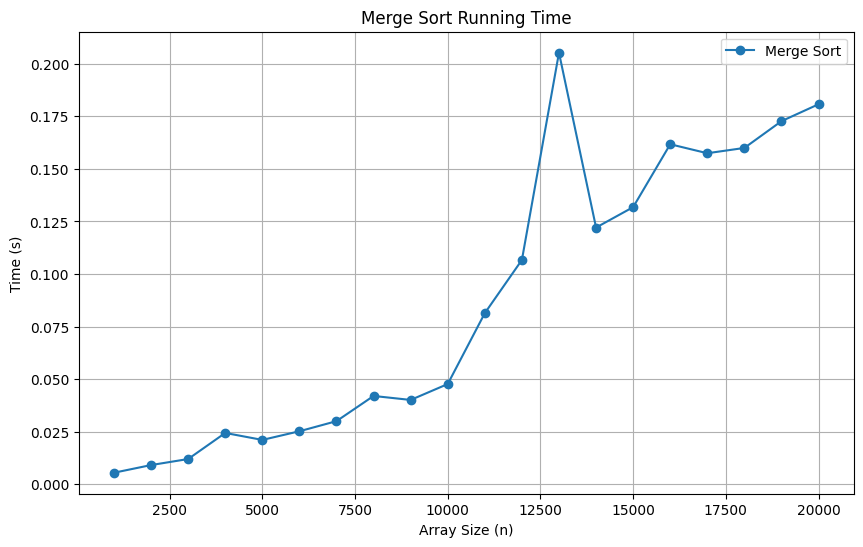

In [13]:
import matplotlib.pyplot as plt

def plot_merge_sort_time(data):
    sizes = [item[0] for item in data]
    times = [item[1] for item in data]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, marker='o', label="Merge Sort")
    plt.title("Merge Sort Running Time")
    plt.xlabel("Array Size (n)")
    plt.ylabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot the graph
plot_merge_sort_time(data)


In [14]:
def print_merge_sort_time_complexity():
    print("\nTime Complexity Analysis for Merge Sort:")
    print("-------------------------------------------------")
    print("Best Case:")
    print("  - Time Complexity: O(n log n)")
    print("  - Explanation: Occurs when the array is already sorted. "
          "The divide-and-conquer approach always requires log n levels, "
          "and merging at each level takes O(n).")
    print("\nAverage Case:")
    print("  - Time Complexity: O(n log n)")
    print("  - Explanation: For any input array, the algorithm divides it into halves, "
          "recursively sorts, and merges them. The process remains consistent.")
    print("\nWorst Case:")
    print("  - Time Complexity: O(n log n)")
    print("  - Explanation: Even in the worst case, the algorithm divides and merges "
          "in O(n log n) time due to its recursive structure.")
    print("\nSpace Complexity:")
    print("  - Space Complexity: O(n)")
    print("  - Explanation: Temporary arrays are created for merging, "
          "requiring additional memory proportional to the array size.")

# Print time complexity analysis
print_merge_sort_time_complexity()



Time Complexity Analysis for Merge Sort:
-------------------------------------------------
Best Case:
  - Time Complexity: O(n log n)
  - Explanation: Occurs when the array is already sorted. The divide-and-conquer approach always requires log n levels, and merging at each level takes O(n).

Average Case:
  - Time Complexity: O(n log n)
  - Explanation: For any input array, the algorithm divides it into halves, recursively sorts, and merges them. The process remains consistent.

Worst Case:
  - Time Complexity: O(n log n)
  - Explanation: Even in the worst case, the algorithm divides and merges in O(n log n) time due to its recursive structure.

Space Complexity:
  - Space Complexity: O(n)
  - Explanation: Temporary arrays are created for merging, requiring additional memory proportional to the array size.


**QUICK SORT ALGORITHM**


In [15]:
def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + middle + quick_sort(right)


In [16]:
import time
import random

def measure_quick_sort_time():
    data = []
    for n in range(1000, 20001, 1000):  # Array sizes from 1000 to 20000
        arr = [random.randint(1, 10000) for _ in range(n)]
        start_time = time.time()
        quick_sort(arr)
        elapsed_time = time.time() - start_time
        data.append((n, elapsed_time))
    return data

# Generate tabular data
data = measure_quick_sort_time()
print("Array Size\tTime (s)")
for size, elapsed_time in data:
    print(f"{size}\t\t{elapsed_time:.6f}")


Array Size	Time (s)
1000		0.004304
2000		0.006041
3000		0.008815
4000		0.011181
5000		0.014526
6000		0.019360
7000		0.027035
8000		0.022398
9000		0.025184
10000		0.029020
11000		0.037820
12000		0.036004
13000		0.036701
14000		0.038935
15000		0.041671
16000		0.048884
17000		0.052072
18000		0.055424
19000		0.059678
20000		0.061910


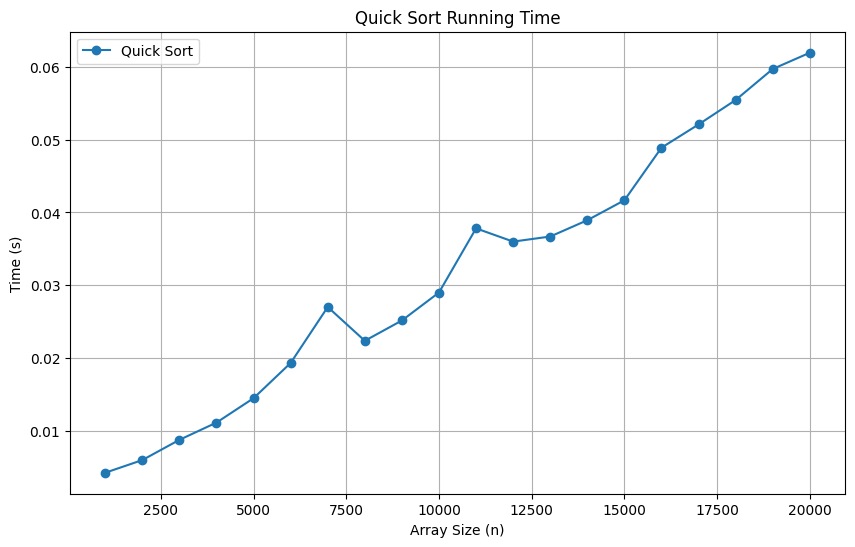

In [17]:
import matplotlib.pyplot as plt

def plot_quick_sort_time(data):
    sizes = [item[0] for item in data]
    times = [item[1] for item in data]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, marker='o', label="Quick Sort")
    plt.title("Quick Sort Running Time")
    plt.xlabel("Array Size (n)")
    plt.ylabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot the graph
plot_quick_sort_time(data)


In [18]:
def print_quick_sort_time_complexity():
    print("\nTime Complexity Analysis for Quick Sort:")
    print("-------------------------------------------------")
    print("Best Case:")
    print("  - Time Complexity: O(n log n)")
    print("  - Explanation: Occurs when the pivot divides the array into two equal halves at each step, "
          "minimizing recursion depth.")
    print("\nAverage Case:")
    print("  - Time Complexity: O(n log n)")
    print("  - Explanation: On average, the pivot divides the array into two reasonably balanced parts, "
          "leading to a logarithmic number of levels.")
    print("\nWorst Case:")
    print("  - Time Complexity: O(n^2)")
    print("  - Explanation: Occurs when the pivot is the smallest or largest element, "
          "resulting in highly unbalanced partitions and linear recursion depth.")
    print("\nSpace Complexity:")
    print("  - Space Complexity: O(log n) for best/average cases (due to recursion stack) "
          "and O(n) for worst case.")

# Print time complexity analysis
print_quick_sort_time_complexity()



Time Complexity Analysis for Quick Sort:
-------------------------------------------------
Best Case:
  - Time Complexity: O(n log n)
  - Explanation: Occurs when the pivot divides the array into two equal halves at each step, minimizing recursion depth.

Average Case:
  - Time Complexity: O(n log n)
  - Explanation: On average, the pivot divides the array into two reasonably balanced parts, leading to a logarithmic number of levels.

Worst Case:
  - Time Complexity: O(n^2)
  - Explanation: Occurs when the pivot is the smallest or largest element, resulting in highly unbalanced partitions and linear recursion depth.

Space Complexity:
  - Space Complexity: O(log n) for best/average cases (due to recursion stack) and O(n) for worst case.


**N-queens Algorithm**



In [19]:
def is_safe(board, row, col, n):
    # Check this row on the left
    for i in range(col):
        if board[row][i] == 1:
            return False

    # Check upper diagonal on the left
    for i, j in zip(range(row, -1, -1), range(col, -1, -1)):
        if board[i][j] == 1:
            return False

    # Check lower diagonal on the left
    for i, j in zip(range(row, n), range(col, -1, -1)):
        if board[i][j] == 1:
            return False

    return True

def solve_n_queens_util(board, col, n):
    if col >= n:
        return True

    for i in range(n):
        if is_safe(board, i, col, n):
            board[i][col] = 1

            if solve_n_queens_util(board, col + 1, n):
                return True

            board[i][col] = 0  # Backtrack

    return False

def solve_n_queens(n):
    board = [[0 for _ in range(n)] for _ in range(n)]
    if not solve_n_queens_util(board, 0, n):
        return None
    return board


In [20]:
import time

def measure_n_queens_time():
    data = []
    for n in range(4, 15):  # Test for board sizes 4x4 to 14x14
        start_time = time.time()
        solve_n_queens(n)
        elapsed_time = time.time() - start_time
        data.append((n, elapsed_time))
    return data

# Generate tabular data
data = measure_n_queens_time()
print("Board Size (n)\tTime (s)")
for size, elapsed_time in data:
    print(f"{size}\t\t{elapsed_time:.6f}")


Board Size (n)	Time (s)
4		0.000063
5		0.000023
6		0.000187
7		0.000051
8		0.001046
9		0.000436
10		0.001099
11		0.000627
12		0.005616
13		0.002707
14		0.032337


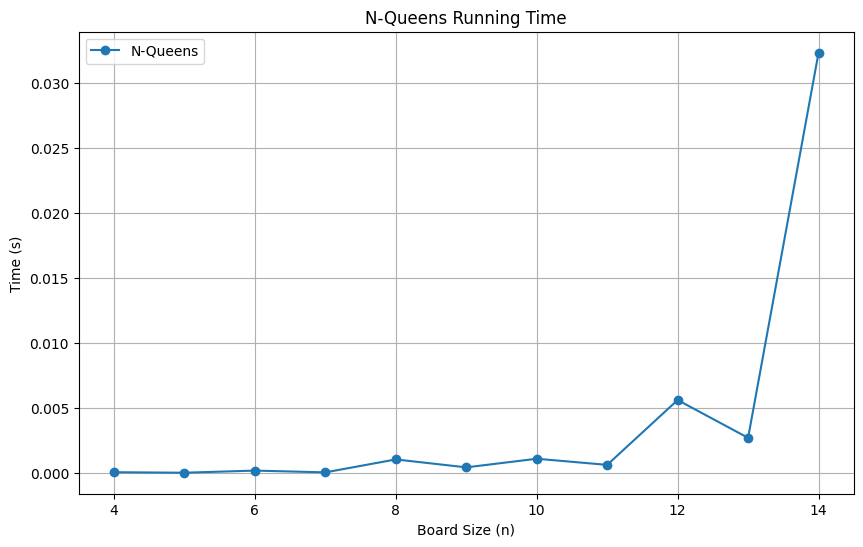

In [21]:
import matplotlib.pyplot as plt

def plot_n_queens_time(data):
    sizes = [item[0] for item in data]
    times = [item[1] for item in data]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, marker='o', label="N-Queens")
    plt.title("N-Queens Running Time")
    plt.xlabel("Board Size (n)")
    plt.ylabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot the graph
plot_n_queens_time(data)


In [22]:
def print_n_queens_time_complexity():
    print("\nTime Complexity Analysis for N-Queens:")
    print("-------------------------------------------------")
    print("Best Case:")
    print("  - Time Complexity: O(n!)")
    print("  - Explanation: In the most optimal case, we still need to explore "
          "a factorial number of configurations for the n queens.")
    print("\nAverage Case:")
    print("  - Time Complexity: O(n!)")
    print("  - Explanation: On average, the backtracking algorithm explores "
          "a significant portion of the search space.")
    print("\nWorst Case:")
    print("  - Time Complexity: O(n!)")
    print("  - Explanation: The algorithm must explore all possible configurations "
          "in the search space for placing the queens.")
    print("\nSpace Complexity:")
    print("  - Space Complexity: O(n^2) for the board and O(n) for the recursion stack.")

# Print time complexity analysis
print_n_queens_time_complexity()



Time Complexity Analysis for N-Queens:
-------------------------------------------------
Best Case:
  - Time Complexity: O(n!)
  - Explanation: In the most optimal case, we still need to explore a factorial number of configurations for the n queens.

Average Case:
  - Time Complexity: O(n!)
  - Explanation: On average, the backtracking algorithm explores a significant portion of the search space.

Worst Case:
  - Time Complexity: O(n!)
  - Explanation: The algorithm must explore all possible configurations in the search space for placing the queens.

Space Complexity:
  - Space Complexity: O(n^2) for the board and O(n) for the recursion stack.


**Travelling Salesman Problem**

In [23]:
from itertools import permutations

def tsp_brute_force(graph, start=0):
    n = len(graph)
    vertices = list(range(n))
    vertices.remove(start)
    min_cost = float('inf')

    for perm in permutations(vertices):
        current_cost = 0
        k = start
        for j in perm:
            current_cost += graph[k][j]
            k = j
        current_cost += graph[k][start]  # Return to start

        min_cost = min(min_cost, current_cost)

    return min_cost


In [24]:
import time
import random

def generate_graph(n):
    """Generate a random graph with n nodes."""
    return [[random.randint(1, 100) if i != j else 0 for j in range(n)] for i in range(n)]

def measure_tsp_time():
    data = []
    for n in range(4, 11):  # Test for graph sizes 4 to 10 nodes
        graph = generate_graph(n)
        start_time = time.time()
        tsp_brute_force(graph)
        elapsed_time = time.time() - start_time
        data.append((n, elapsed_time))
    return data

# Generate tabular data
data = measure_tsp_time()
print("Number of Cities (n)\tTime (s)")
for cities, elapsed_time in data:
    print(f"{cities}\t\t\t{elapsed_time:.6f}")


Number of Cities (n)	Time (s)
4			0.000021
5			0.000038
6			0.000157
7			0.001094
8			0.010201
9			0.041681
10			0.518210


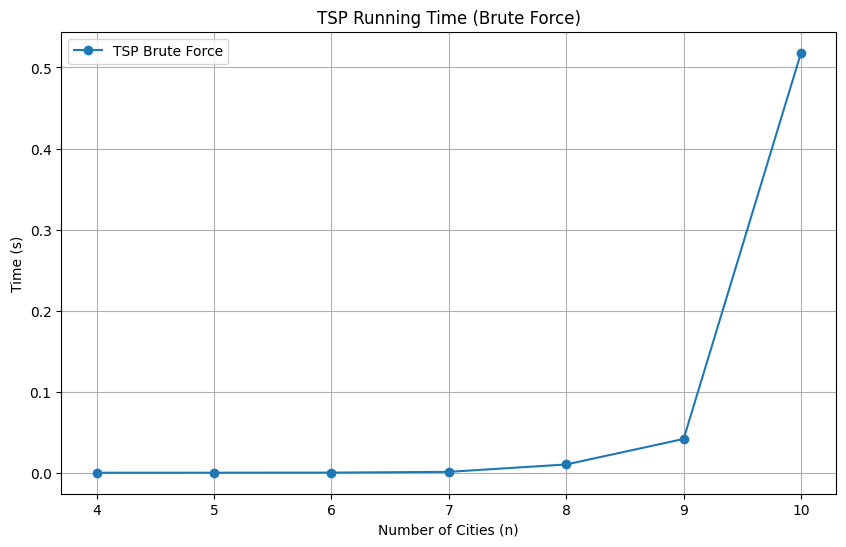

In [25]:
import matplotlib.pyplot as plt

def plot_tsp_time(data):
    sizes = [item[0] for item in data]
    times = [item[1] for item in data]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, marker='o', label="TSP Brute Force")
    plt.title("TSP Running Time (Brute Force)")
    plt.xlabel("Number of Cities (n)")
    plt.ylabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot the graph
plot_tsp_time(data)


In [26]:
def print_tsp_time_complexity():
    print("\nTime Complexity Analysis for TSP (Brute Force):")
    print("-------------------------------------------------")
    print("Best Case:")
    print("  - Time Complexity: O(n!)")
    print("  - Explanation: Even in the best case, we need to explore all permutations "
          "of cities to guarantee finding the shortest path.")
    print("\nAverage Case:")
    print("  - Time Complexity: O(n!)")
    print("  - Explanation: On average, the algorithm computes all possible paths "
          "to find the optimal solution.")
    print("\nWorst Case:")
    print("  - Time Complexity: O(n!)")
    print("  - Explanation: The algorithm must calculate all n! permutations of cities.")
    print("\nSpace Complexity:")
    print("  - Space Complexity: O(n) for storing the recursion stack and O(n^2) for the graph.")

# Print time complexity analysis
print_tsp_time_complexity()



Time Complexity Analysis for TSP (Brute Force):
-------------------------------------------------
Best Case:
  - Time Complexity: O(n!)
  - Explanation: Even in the best case, we need to explore all permutations of cities to guarantee finding the shortest path.

Average Case:
  - Time Complexity: O(n!)
  - Explanation: On average, the algorithm computes all possible paths to find the optimal solution.

Worst Case:
  - Time Complexity: O(n!)
  - Explanation: The algorithm must calculate all n! permutations of cities.

Space Complexity:
  - Space Complexity: O(n) for storing the recursion stack and O(n^2) for the graph.
